# MODEL BUILDING

Including:

- Feature Engineering
- Feature Selection
- Model Iterations

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import CategoricalDtype


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

sns.set_theme(style="whitegrid", context="notebook")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, brier_score_loss,
    ConfusionMatrixDisplay, classification_report
)

import joblib
import os

In [12]:
df = pd.read_csv('../datasets/cleaned_data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   year                        869319 non-null  int64  
 1   age_group                   869319 non-null  str    
 2   age                         869319 non-null  float64
 3   sex                         869319 non-null  str    
 4   race                        869319 non-null  str    
 5   weight                      869319 non-null  float64
 6   height                      869319 non-null  float64
 7   bmi                         869319 non-null  float64
 8   marital_status              869319 non-null  str    
 9   education_level             869319 non-null  str    
 10  education                   869319 non-null  float64
 11  employment_status           869319 non-null  str    
 12  income_level                869319 non-null  str    
 13  income                   

In [3]:
df.columns

Index(['year', 'age_group', 'age', 'sex', 'race', 'weight', 'height', 'bmi',
       'marital_status', 'education_level', 'education', 'employment_status',
       'income_level', 'income', 'general_health', 'gen_health',
       'physical_health_days', 'mental_health_days', 'exercise',
       'smoked_100_cigarettes', 'drinks_alcohol', 'high_bp', 'had_stroke',
       'had_heart_attack', 'had_coronary_heart_disease', 'cost_barrier',
       'last_checkup', 'l_checkup', 'has_personal_doctor', 'diabetes'],
      dtype='str')

In [11]:
df.head()

,year,age_group,age,sex,race,weight,height,bmi,marital_status,education_level,education,employment_status,income_level,income,general_health,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,last_checkup,l_checkup,has_personal_doctor,diabetes
0,2019,40 - 44,5.0,Female,White,220.0,66.0,35.51,Never married,Some college (1-3 years) or Technical school,5.0,A homemaker,"<$10,000",1.0,Very Good,2.0,0.0,30.0,False,True,False,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Non-diabetic
1,2019,60 - 64,9.0,Male,White,150.0,66.0,24.21,Divorced,Some college (1-3 years) or Technical school,5.0,Unable to work,"<$10,000",1.0,Fair,4.0,3.0,12.0,True,True,False,Yes,False,False,False,False,<1 year,1.0,No,Non-diabetic
2,2019,45 - 49,6.0,Female,White,148.0,61.0,27.96,Divorced,High school graduate (12 or GED),4.0,Employed for wages,"<$10,000",1.0,Good,3.0,0.0,10.0,True,True,True,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Diabetic
3,2019,45 - 49,6.0,Male,White,220.0,71.0,30.68,Married,High school graduate (12 or GED),4.0,Employed for wages,"$75,000 - <$100,000",8.0,Very Good,2.0,0.0,0.0,True,True,False,No,False,False,False,False,<1 year,1.0,No,Non-diabetic
4,2019,65 - 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,High school graduate (12 or GED),4.0,Retired,"$15,000 - <$20,000",3.0,Fair,4.0,30.0,0.0,False,True,False,Yes,True,False,False,False,<1 year,1.0,"Yes, only one",Diabetic


### Feature Selection

To drop:
- year
- age group
- race (won't be relevant for this model)
- weight and height (multicolinearity with bmi, which is a derivative of both)
- education_level
- income level
- general health
- last_checkup

Recode general health, so that: Excellent is 5, and Poor is 1

In [12]:
df.general_health.value_counts()

general_health
Very Good    303836
Good         274836
Excellent    144028
Fair         110367
Poor          36252
Name: count, dtype: int64

In [13]:
df.gen_health.value_counts()

gen_health
2.0    303836
3.0    274836
1.0    144028
4.0    110367
5.0     36252
Name: count, dtype: int64

In [ ]:
df.gen_health = 6 - df.gen_health
df.head()

,year,age_group,age,sex,race,weight,height,bmi,marital_status,education_level,education,employment_status,income_level,income,general_health,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,last_checkup,l_checkup,has_personal_doctor,diabetes
0,2019,40 - 44,5.0,Female,White,220.0,66.0,35.51,Never married,Some college (1-3 years) or Technical school,5.0,A homemaker,"<$10,000",1.0,Very Good,4.0,0.0,30.0,False,True,False,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Non-diabetic
1,2019,60 - 64,9.0,Male,White,150.0,66.0,24.21,Divorced,Some college (1-3 years) or Technical school,5.0,Unable to work,"<$10,000",1.0,Fair,2.0,3.0,12.0,True,True,False,Yes,False,False,False,False,<1 year,1.0,No,Non-diabetic
2,2019,45 - 49,6.0,Female,White,148.0,61.0,27.96,Divorced,High school graduate (12 or GED),4.0,Employed for wages,"<$10,000",1.0,Good,3.0,0.0,10.0,True,True,True,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Diabetic
3,2019,45 - 49,6.0,Male,White,220.0,71.0,30.68,Married,High school graduate (12 or GED),4.0,Employed for wages,"$75,000 - <$100,000",8.0,Very Good,4.0,0.0,0.0,True,True,False,No,False,False,False,False,<1 year,1.0,No,Non-diabetic
4,2019,65 - 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,High school graduate (12 or GED),4.0,Retired,"$15,000 - <$20,000",3.0,Fair,2.0,30.0,0.0,False,True,False,Yes,True,False,False,False,<1 year,1.0,"Yes, only one",Diabetic


In [ ]:
df.gen_health = 6 - df.gen_health
df.head()

to_drop = ['year', 'age_group', 'race', 'weight', 'height', 'education_level', 'income_level',
           'general_health', 'last_checkup']

df.drop(columns=to_drop, inplace=True)
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         869319 non-null  float64
 1   sex                         869319 non-null  str    
 2   bmi                         869319 non-null  float64
 3   marital_status              869319 non-null  str    
 4   education                   869319 non-null  float64
 5   employment_status           869319 non-null  str    
 6   income                      869319 non-null  float64
 7   gen_health                  869319 non-null  float64
 8   physical_health_days        869319 non-null  float64
 9   mental_health_days          869319 non-null  float64
 10  exercise                    869319 non-null  bool   
 11  smoked_100_cigarettes       869319 non-null  bool   
 12  drinks_alcohol              869319 non-null  bool   
 13  high_bp                  

,age,sex,bmi,marital_status,education,employment_status,income,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,l_checkup,has_personal_doctor,diabetes
0,5.0,Female,35.51,Never married,5.0,A homemaker,1.0,4.0,0.0,30.0,False,True,False,Yes,False,False,False,False,1.0,"Yes, only one",Non-diabetic
1,9.0,Male,24.21,Divorced,5.0,Unable to work,1.0,2.0,3.0,12.0,True,True,False,Yes,False,False,False,False,1.0,No,Non-diabetic
2,6.0,Female,27.96,Divorced,4.0,Employed for wages,1.0,3.0,0.0,10.0,True,True,True,Yes,False,False,False,False,1.0,"Yes, only one",Diabetic
3,6.0,Male,30.68,Married,4.0,Employed for wages,8.0,4.0,0.0,0.0,True,True,False,No,False,False,False,False,1.0,No,Non-diabetic
4,10.0,Male,37.33,Widowed,4.0,Retired,3.0,2.0,30.0,0.0,False,True,False,Yes,True,False,False,False,1.0,"Yes, only one",Diabetic


Change all True/False and Yes/No's to zero's and one's

In [18]:
df.high_bp.value_counts()

high_bp
No            506765
Yes           353556
Borderline      8998
Name: count, dtype: int64

In [29]:
# compiled preprocessing
def wrangle(filepath="../datasets/cleaned_data.csv"):
    # read cleaned data
    df = pd.read_csv(filepath)

    # invert direction of general health so that higher values mean better health
    df.gen_health = 6 - df.gen_health

    # drop redundant and low cardinality features
    to_drop = ['year', 'age_group', 'race', 'weight', 'height', 'education_level', 'income_level',
            'general_health', 'last_checkup']
    df.drop(columns=to_drop, inplace=True)

    # convert True/False columns (boolean) to integers
    t_f_cols = ['smoked_100_cigarettes', 'drinks_alcohol', 'had_stroke', 'had_heart_attack', 'had_coronary_heart_disease', 'cost_barrier']
    for col in t_f_cols:
        df[col] = df[col].astype('int8')

    return df


df = wrangle()

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         869319 non-null  float64
 1   sex                         869319 non-null  str    
 2   bmi                         869319 non-null  float64
 3   marital_status              869319 non-null  str    
 4   education                   869319 non-null  float64
 5   employment_status           869319 non-null  str    
 6   income                      869319 non-null  float64
 7   gen_health                  869319 non-null  float64
 8   physical_health_days        869319 non-null  float64
 9   mental_health_days          869319 non-null  float64
 10  exercise                    869319 non-null  bool   
 11  smoked_100_cigarettes       869319 non-null  int8   
 12  drinks_alcohol              869319 non-null  int8   
 13  high_bp                  

In [45]:
df.head()

,age,sex,bmi,marital_status,education,employment_status,income,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,l_checkup,has_personal_doctor,diabetes
0,5.0,Female,35.51,Never married,5.0,A homemaker,1.0,4.0,0.0,30.0,False,1,0,Yes,0,0,0,0,1.0,"Yes, only one",Non-diabetic
1,9.0,Male,24.21,Divorced,5.0,Unable to work,1.0,2.0,3.0,12.0,True,1,0,Yes,0,0,0,0,1.0,No,Non-diabetic
2,6.0,Female,27.96,Divorced,4.0,Employed for wages,1.0,3.0,0.0,10.0,True,1,1,Yes,0,0,0,0,1.0,"Yes, only one",Diabetic
3,6.0,Male,30.68,Married,4.0,Employed for wages,8.0,4.0,0.0,0.0,True,1,0,No,0,0,0,0,1.0,No,Non-diabetic
4,10.0,Male,37.33,Widowed,4.0,Retired,3.0,2.0,30.0,0.0,False,1,0,Yes,1,0,0,0,1.0,"Yes, only one",Diabetic


In [48]:
df[['had_heart_attack', 'had_coronary_heart_disease']].corr()

,had_heart_attack,had_coronary_heart_disease
had_heart_attack,1.000000,0.448444
had_coronary_heart_disease,0.448444,1.000000


<Axes: xlabel='high_bp', ylabel='count'>

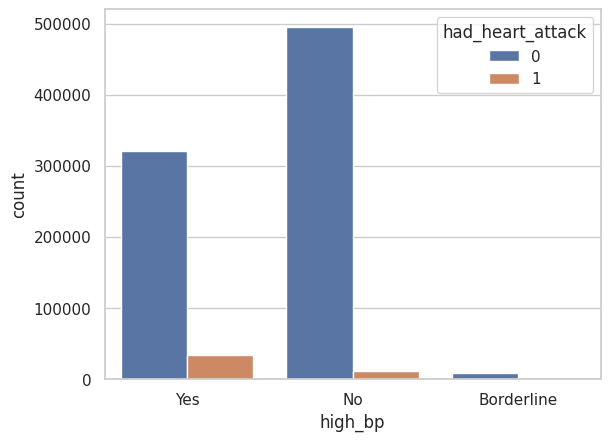

In [ ]:
sns.histplot(data=df, x='high_bp', hue='had_heart_attack')

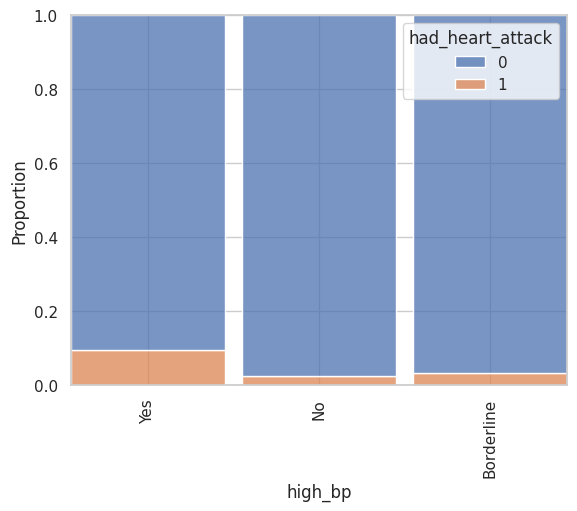

In [50]:
sns.histplot(data=df, x='high_bp', hue='had_heart_attack', multiple='fill', stat='proportion', shrink=0.9)
plt.xticks(rotation=90);

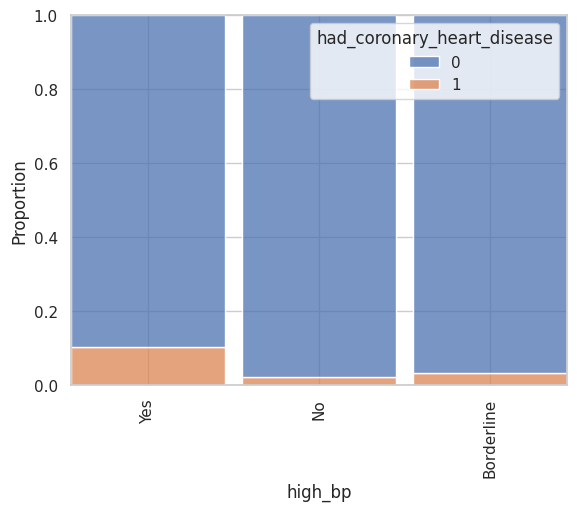

In [52]:
sns.histplot(data=df, x='high_bp', hue='had_coronary_heart_disease', multiple='fill', stat='proportion', shrink=0.9)
plt.xticks(rotation=90);

### Random Guess

In [54]:
df.diabetes.value_counts(normalize=True)

diabetes
Non-diabetic    0.844349
Diabetic        0.133089
Pre-diabetic    0.022561
Name: proportion, dtype: float64

### Split Data

In [37]:
df_1 = df.copy()

In [32]:
target = 'diabetes'

y = df_1[target]
X = df_1.drop(columns=[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)

print(f"Training...\nFeatures:  {len(X_train)}\tTarget:  {len(y_train)}")
print(f"Testing...\nFeatures:  {len(X_test)}\tTarget:  {len(y_test)}")

Training...
Features:  825853	Target:  825853
Testing...
Features:  43466	Target:  43466


In [21]:
y_train.value_counts(normalize=True)

diabetes
Non-diabetic    0.844350
Diabetic        0.133089
Pre-diabetic    0.022561
Name: proportion, dtype: float64

In [22]:
y_test.value_counts(normalize=True)

diabetes
Non-diabetic    0.844338
Diabetic        0.133093
Pre-diabetic    0.022569
Name: proportion, dtype: float64

### Baseline Model with Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression

# build column transformer
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(exclude='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# build pipeline
logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LogisticRegression(random_state=42))
])


logreg.fit(X_train, y_train)

lr_pred = logreg.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, lr_pred)}")
acc = accuracy_score(y_test, lr_pred)



Accuracy: 0.8476740440804307


In [12]:
confusion_matrix(y_test, lr_pred)

array([[  934,  4851,     0],
       [  789, 35911,     0],
       [   74,   907,     0]])

In [13]:
print(logreg.classes_)

['Diabetic' 'Non-diabetic' 'Pre-diabetic']


In [16]:
print(classification_report(
    y_test, lr_pred,
    target_names=logreg.classes_
))

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    Diabetic       0.52      0.16      0.25      5785
Non-diabetic       0.86      0.98      0.92     36700
Pre-diabetic       0.00      0.00      0.00       981

    accuracy                           0.85     43466
   macro avg       0.46      0.38      0.39     43466
weighted avg       0.80      0.85      0.81     43466



/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [19]:
ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred));

### Feature Engineering

#### Collapse diabetes into two classes

In [20]:
df_1.diabetes.unique()

<ArrowStringArray>
['Non-diabetic', 'Diabetic', 'Pre-diabetic']
Length: 3, dtype: str

In [34]:
df.diabetes.value_counts()

diabetes
Non-diabetic    734009
Diabetic        115697
Pre-diabetic     19613
Name: count, dtype: int64

In [38]:
df_1['diabetes'] = df_1['diabetes'].map({'Non-diabetic': 0, 'Pre-diabetic': 1, 'Diabetic': 1})
df_1.diabetes.value_counts()

diabetes
0    734009
1    135310
Name: count, dtype: int64

#### Redo baseline model

In [40]:
target = 'diabetes'

y = df_1[target]
X = df_1.drop(columns=[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)

print(f"Training...\nFeatures:  {len(X_train)}\tTarget:  {len(y_train)}")
print(f"Testing...\nFeatures:  {len(X_test)}\tTarget:  {len(y_test)}")

Training...
Features:  825853	Target:  825853
Testing...
Features:  43466	Target:  43466


In [41]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

diabetes
0    0.84435
1    0.15565
Name: proportion, dtype: float64
diabetes
0    0.844338
1    0.155662
Name: proportion, dtype: float64


In [53]:
# build pipeline
logreg2 = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LogisticRegression(random_state=42, class_weight='balanced'))
])


logreg2.fit(X_train, y_train)

lr_pred2 = logreg2.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, lr_pred2)}")
acc = accuracy_score(y_test, lr_pred2)
tn, fp, fn, tp = confusion_matrix(y_test, lr_pred2).ravel()
lr_prob = logreg2.predict_proba(X_test)[:, 1]

Accuracy: 0.7287765149772236


In [44]:
def evaluate_model(name, y_true, y_pred, y_prob):
    """
    Evaluate a binary classifier.
    
    Parameters
    ----------
    name   : str   — model name, used in plot title and dict key
    y_true : array — true labels
    y_pred : array — predicted labels
    y_prob : array — predicted probabilities for positive class
    
    Returns
    -------
    dict of metrics
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        'model'       : name,
        'accuracy'    : accuracy_score(y_true, y_pred),
        'sensitivity' : tp / (tp + fn),
        'specificity' : tn / (tn + fp),
        'ppv'         : tp / (tp + fp),
        'npv'         : tn / (tn + fn),
        'f1'          : tp / (tp + 0.5 * (fp + fn)),   # equivalent, no division chain
        'roc_auc'     : roc_auc_score(y_true, y_prob),
        'avg_precision': average_precision_score(y_true, y_prob),
        'brier'       : brier_score_loss(y_true, y_prob),
    }

    # ── Print ─────────────────────────────────────────────────────────────────
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    for k, v in metrics.items():
        if k == 'model': continue
        print(f"  {k:<18} {v:.4f}")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(name, fontsize=12, fontweight='bold')

    # Confusion matrix
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['Non-diabetic', 'Diabetic']
    ).plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title('Confusion matrix')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, color='steelblue',
                 label=f"AUC = {metrics['roc_auc']:.3f}")
    axes[1].plot([0,1],[0,1], 'k--', linewidth=0.8)
    axes[1].set_xlabel('1 - Specificity')
    axes[1].set_ylabel('Sensitivity')
    axes[1].set_title('ROC curve')
    axes[1].legend()

    # Precision-Recall curve
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    axes[2].plot(rec, prec, color='coral',
                 label=f"AP = {metrics['avg_precision']:.3f}")
    axes[2].axhline(y_true.mean(), linestyle='--', color='gray',
                    linewidth=0.8, label=f"Baseline = {y_true.mean():.3f}")
    axes[2].set_xlabel('Recall (Sensitivity)')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall curve')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(f"{name.lower().replace(' ', '_')}_eval.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    return metrics

In [47]:
logreg2.classes_

array([0, 1])


────────────────────────────────────────
  logreg2
────────────────────────────────────────
  accuracy           0.7288
  sensitivity        0.7790
  specificity        0.7195
  ppv                0.3386
  npv                0.9464
  f1                 0.4721
  roc_auc            0.8205
  avg_precision      0.4334
  brier              0.1784


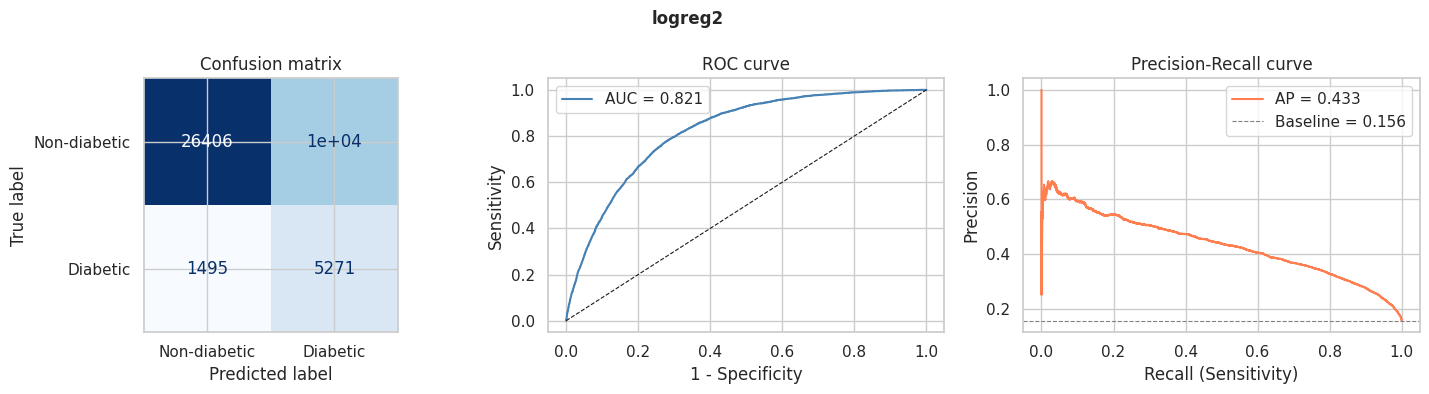

In [54]:
metrics = evaluate_model('logreg2', y_test, lr_pred2,lr_prob)

In [48]:
print(logreg2.classes_)
print(logreg2.predict_proba(X_test[:5]))
print(y_test[:5].values)

[0 1]
[[0.89912224 0.10087776]
 [0.73219988 0.26780012]
 [0.61380535 0.38619465]
 [0.9950285  0.0049715 ]
 [0.57140312 0.42859688]]
[0 0 0 0 0]


In [49]:
logreg2.named_steps

{'preprocessor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                  ['age', 'bmi', 'education', 'income',
                                   'gen_health', 'physical_health_days',
                                   'mental_health_days', 'smoked_100_cigarettes',
                                   'drinks_alcohol', 'had_stroke',
                                   'had_heart_attack',
                                   'had_coronary_heart_disease', 'cost_barrier',
                                   'l_checkup']),
                                 ('cat', OneHotEncoder(handle_unknown='ignore'),
                                  ['sex', 'marital_status', 'employment_status',
                                   'exercise', 'high_bp',
                                   'has_personal_doctor'])]),
 'lr': LogisticRegression(random_state=42)}

In [55]:
df_1.head()

,age,sex,bmi,marital_status,education,employment_status,income,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,l_checkup,has_personal_doctor,diabetes
0,5.0,Female,35.51,Never married,5.0,A homemaker,1.0,4.0,0.0,30.0,False,1,0,Yes,0,0,0,0,1.0,"Yes, only one",0
1,9.0,Male,24.21,Divorced,5.0,Unable to work,1.0,2.0,3.0,12.0,True,1,0,Yes,0,0,0,0,1.0,No,0
2,6.0,Female,27.96,Divorced,4.0,Employed for wages,1.0,3.0,0.0,10.0,True,1,1,Yes,0,0,0,0,1.0,"Yes, only one",1
3,6.0,Male,30.68,Married,4.0,Employed for wages,8.0,4.0,0.0,0.0,True,1,0,No,0,0,0,0,1.0,No,0
4,10.0,Male,37.33,Widowed,4.0,Retired,3.0,2.0,30.0,0.0,False,1,0,Yes,1,0,0,0,1.0,"Yes, only one",1


**Collapse Marital Status**

In [56]:
df.marital_status.value_counts()

marital_status
Married                            466060
Never married                      146122
Divorced                           116848
Widowed                             86880
A member of an unmarried couple     36757
Separated                           16652
Name: count, dtype: int64

In [57]:
df_1['marital_status'] = df_1['marital_status'].map({
    'Married': 'Married/Cohabiting',
    'A member of an unmarried couple': 'Married/Cohabiting',
    'Never married': 'Single',
    'Divorced': 'Previously Married',
    'Separated': 'Previously Married',
    'Widowed': 'Previously Married'
})

print(df_1.marital_status.value_counts())

marital_status
Married/Cohabiting    502817
Previously Married    220380
Single                146122
Name: count, dtype: int64


**Collapse employment status**

In [58]:
df.employment_status.value_counts()

employment_status
Employed for wages                  394329
Retired                             258061
Self-employed                        80455
Unable to work                       49618
A homemaker                          33487
A student                            19290
Out of work for less that 1 year     17513
Out of work for more than 1 year     16566
Name: count, dtype: int64

In [59]:
df_1['employment_status'] = df_1['employment_status'].map({
    'Employed for wages': 'Employed',
    'Self-employed': 'Employed',
    'Retired': 'Retired',
    'Out of work for less that 1 year': 'Unemployed',
    'Out of work for more than 1 year': 'Unemployed',
    'A homemaker': 'Student/Homemaker',
    'A student': 'Student/Homemaker',
    'Unable to work': 'Unable to work'
})

df_1.employment_status.value_counts()

employment_status
Employed             474784
Retired              258061
Student/Homemaker     52777
Unable to work        49618
Unemployed            34079
Name: count, dtype: int64

#### Rebuild Model

In [60]:
target = 'diabetes'

y = df_1[target]
X = df_1.drop(columns=[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)

print(f"Training...\nFeatures:  {len(X_train)}\tTarget:  {len(y_train)}")
print(f"Testing...\nFeatures:  {len(X_test)}\tTarget:  {len(y_test)}")

Training...
Features:  825853	Target:  825853
Testing...
Features:  43466	Target:  43466


Accuracy: 0.728592463074587

────────────────────────────────────────
  logreg2
────────────────────────────────────────
  accuracy           0.7286
  sensitivity        0.7780
  specificity        0.7195
  ppv                0.3383
  npv                0.9462
  f1                 0.4716
  roc_auc            0.8203
  avg_precision      0.4326
  brier              0.1785


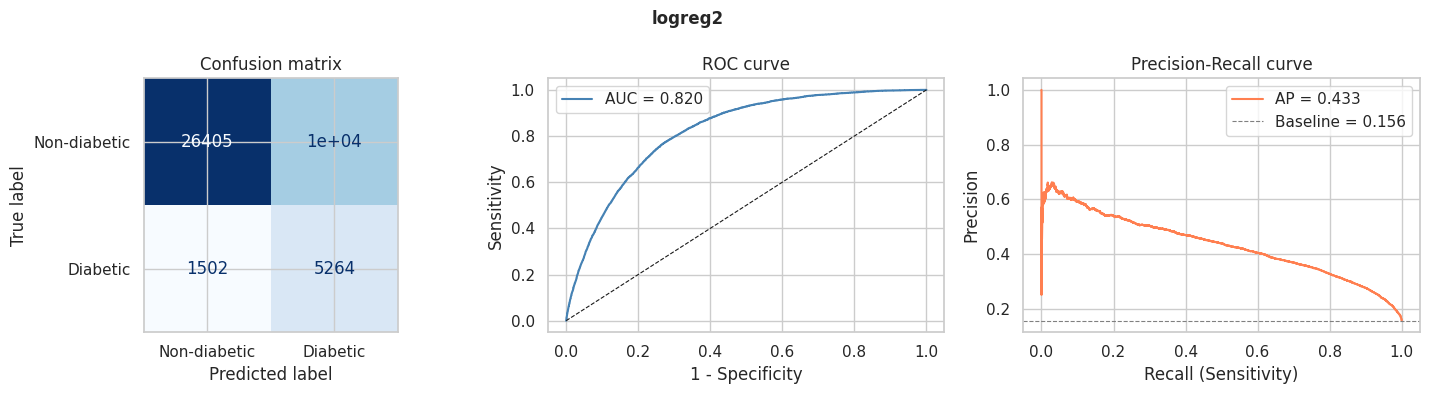

In [61]:
# build pipeline
logreg3 = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LogisticRegression(random_state=42, class_weight='balanced'))
])


logreg3.fit(X_train, y_train)

lr_pred3 = logreg3.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, lr_pred3)}")
# acc = accuracy_score(y_test, lr_pred3)
tn, fp, fn, tp = confusion_matrix(y_test, lr_pred3).ravel()
lr_prob3 = logreg3.predict_proba(X_test)[:, 1]

metrics = evaluate_model('logreg2', y_test, lr_pred3, lr_prob3)